In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OneHotEncoder,MultiLabelBinarizer,LabelEncoder,MinMaxScaler,StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import ADASYN
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model
from sklearn.utils import class_weight
from sklearn.metrics import classification_report
import numpy as np

In [2]:
data=pd.read_csv('Lending_Loan_Company_Data_Analysis.csv')
data

,Credit_Policy,Loan_Purpose,Interest_Rate,Monthly_Installment,Natural_log_Annual_Income,Debt_Income_Ratio,FICO_Score,Days_with_Credit_Line,Revolving_Balance,Revolving_Utilization,Enquiries_Last_6_Months,Deliquency_Last_2_Yrs,Public_Derogatory_Records,Paid_Status
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,Paid
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,Paid
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,Paid
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,Paid
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,Paid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0,all_other,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,Unpaid
9574,0,all_other,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,Unpaid
9575,0,debt_consolidation,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,Unpaid
9576,0,home_improvement,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,Unpaid


In [3]:
data_copy=data.copy()

In [4]:
enc=LabelEncoder()
data_copy['Loan_Purpose_Enc']=enc.fit_transform(data_copy['Loan_Purpose'])
data_copy['Paid_Status_Enc']=enc.fit_transform(data_copy['Paid_Status'])
data_copy['Interest_Debt_Ratio'] = data_copy['Interest_Rate'] * data_copy['Debt_Income_Ratio']
data_copy

,Credit_Policy,Loan_Purpose,Interest_Rate,Monthly_Installment,Natural_log_Annual_Income,Debt_Income_Ratio,FICO_Score,Days_with_Credit_Line,Revolving_Balance,Revolving_Utilization,Enquiries_Last_6_Months,Deliquency_Last_2_Yrs,Public_Derogatory_Records,Paid_Status,Loan_Purpose_Enc,Paid_Status_Enc,Interest_Debt_Ratio
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,Paid,2,0,2.316172
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,Paid,1,0,1.530459
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,Paid,2,0,1.578191
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,Paid,2,0,0.816480
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,Paid,1,0,2.134722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0,all_other,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,Unpaid,0,1,1.517979
9574,0,all_other,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,Unpaid,0,1,0.026313
9575,0,debt_consolidation,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,Unpaid,2,1,1.401939
9576,0,home_improvement,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,Unpaid,4,1,3.068800


In [5]:
def Interest_Debt_Ratio(a):
    if a<0.803024:
        return 'Lower Risk'
    elif 0.803024<=a<2.260168:
        return 'Medium Risk'
    else:
        return 'Higher Risk'

data_copy['Interest_Debt_Income_Ratio'] = data_copy['Interest_Debt_Ratio'].apply(Interest_Debt_Ratio)
data_copy

,Credit_Policy,Loan_Purpose,Interest_Rate,Monthly_Installment,Natural_log_Annual_Income,Debt_Income_Ratio,FICO_Score,Days_with_Credit_Line,Revolving_Balance,Revolving_Utilization,Enquiries_Last_6_Months,Deliquency_Last_2_Yrs,Public_Derogatory_Records,Paid_Status,Loan_Purpose_Enc,Paid_Status_Enc,Interest_Debt_Ratio,Interest_Debt_Income_Ratio
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,Paid,2,0,2.316172,Higher Risk
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,Paid,1,0,1.530459,Medium Risk
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,Paid,2,0,1.578191,Medium Risk
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,Paid,2,0,0.816480,Medium Risk
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,Paid,1,0,2.134722,Medium Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0,all_other,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,Unpaid,0,1,1.517979,Medium Risk
9574,0,all_other,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,Unpaid,0,1,0.026313,Lower Risk
9575,0,debt_consolidation,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,Unpaid,2,1,1.401939,Medium Risk
9576,0,home_improvement,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,Unpaid,4,1,3.068800,Higher Risk


In [6]:
data_copy['Interest_Debt_Ratio'].describe()

count    9578.000000
mean        1.586740
std         1.000481
min         0.000000
25%         0.803024
50%         1.488924
75%         2.260168
max         5.527170
Name: Interest_Debt_Ratio, dtype: float64

In [7]:
data_num=data_copy.select_dtypes(exclude='object')
corr=data_num.corr()
corr['Paid_Status_Enc'].sort_values(ascending=False)

Paid_Status_Enc              1.000000
Interest_Rate                0.159552
Enquiries_Last_6_Months      0.149452
Interest_Debt_Ratio          0.083733
Revolving_Utilization        0.082088
Revolving_Balance            0.053699
Monthly_Installment          0.049955
Public_Derogatory_Records    0.048634
Loan_Purpose_Enc             0.047907
Debt_Income_Ratio            0.037362
Deliquency_Last_2_Yrs        0.008881
Days_with_Credit_Line       -0.029237
Natural_log_Annual_Income   -0.033439
FICO_Score                  -0.149666
Credit_Policy               -0.158119
Name: Paid_Status_Enc, dtype: float64

# EDA

## 1. Dataset Imbalance ratio

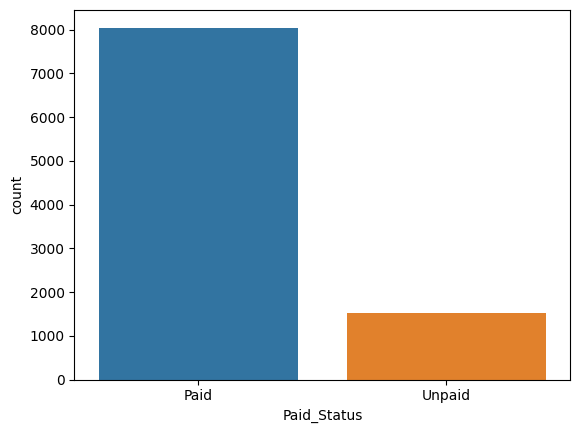

In [10]:
sns.countplot(data=data_copy,x='Paid_Status',hue='Paid_Status')
plt.show()

In [11]:
new=pd.DataFrame(data_copy['Paid_Status'].value_counts())
new.reset_index(inplace=True)
new['Count_%']=round((new['count']/len(data))*100,1)

### We See That, The ratio of Paid & Unpaid % is in the ratio of 84:16 which results in Imbalenced Dataset.

# As The Number of Paid Cases > Unpaid Cases, We are going to focus more on The Causes of Unpaid Loan

## Factors That Increases the Unpaid Cases Count

### 1. FICO Score

#### FICO Score is Indirectly Proportional to Credit Risk.

In [16]:
unpaid=data_copy.loc[data_copy['Paid_Status']=='Unpaid']

In [17]:
def FICO_Score_Range(a):
    if 600<=a<650:
        return '600-649'
    elif 650<=a<700:
        return '650-699'
    elif 700<=a<750:
        return '700-749'
    elif 750<=a<800:
        return '750-799'
    else:
        return '>=800'

unpaid['FICO_Range']=unpaid['FICO_Score'].apply(FICO_Score_Range)

In [18]:
Unpaid_Fico=pd.DataFrame(unpaid['FICO_Range'].value_counts())
Unpaid_Fico.reset_index(inplace=True)

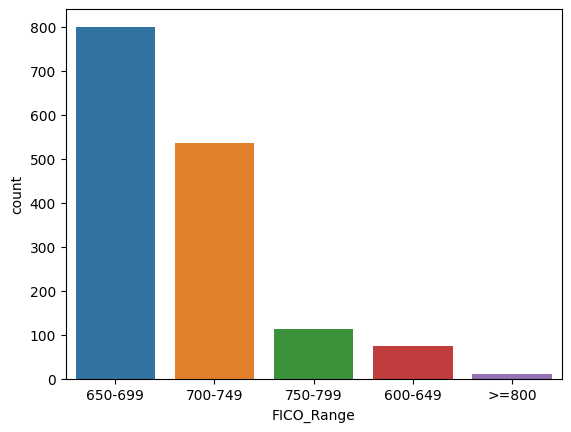

In [19]:
sns.barplot(data=Unpaid_Fico,x='FICO_Range',y='count',hue='FICO_Range')
plt.show()

## The Cases whose FICO Score <750 Results in more Unpaid Loan.

### 2. Interest Rate

### A. Overall Numbers

In [23]:
unpaid['Interest_Rate'].describe()

count    1533.000000
mean        0.132452
std         0.025495
min         0.070500
25%         0.115400
50%         0.131600
75%         0.148200
max         0.216400
Name: Interest_Rate, dtype: float64

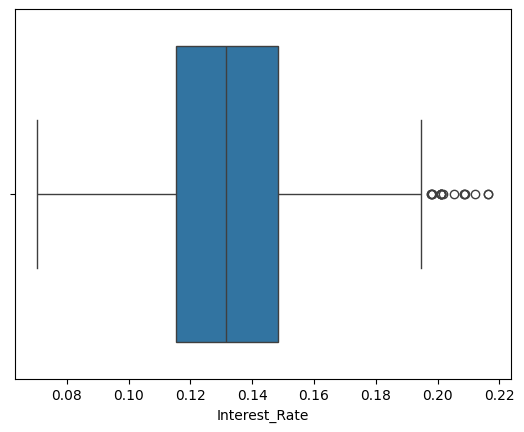

In [24]:
sns.boxplot(data=unpaid,x='Interest_Rate')
plt.show()

In [25]:
def Interest_Rate(a):
    if 0<=a<0.05:
        return '0% - 4%'
    elif 0.05<=a<0.1:
        return '5% - 9%'
    elif 0.1<=a<0.15:
        return '10% - 14%'
    elif 0.15<=a<0.2:
        return '15% - 20%'
    else:
        return '>=20%'

unpaid['Interest_Rate_Range']=unpaid['Interest_Rate'].apply(Interest_Rate)
Unpaid_Interest_Percentage=pd.DataFrame(unpaid['Interest_Rate_Range'].value_counts())
Unpaid_Interest_Percentage.reset_index(inplace=True)

In [26]:
Unpaid_Interest_Percentage['Percentage']=round((Unpaid_Interest_Percentage['count']/len(unpaid)*100),1)

In [27]:
sizes=[i for i in Unpaid_Interest_Percentage['Percentage']]
labels=[i for i in Unpaid_Interest_Percentage['Interest_Rate_Range']]

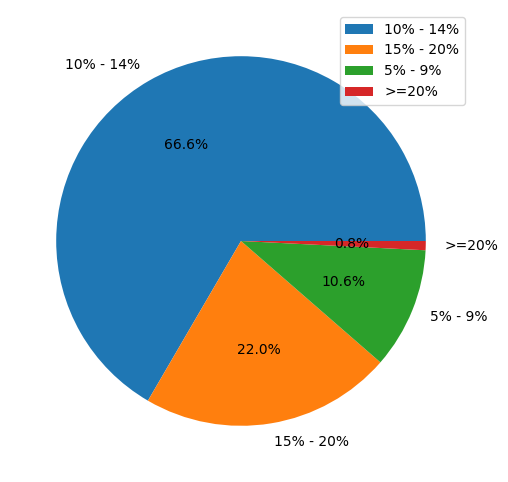

In [28]:
plt.figure(figsize=(6,6))
plt.pie(sizes,labels=labels,autopct='%1.1f%%')
plt.legend()
plt.show()

## The Interest Rates >= 10% have higher % of Unpaid Cases. The More the Interest Rates are, The more Cases becomes Unpaid.

### B. Loan Purpose Where Interest Rates >=20%

In [31]:
Unpaid_Loan_Purpose_Int_20_Perc = unpaid.loc[unpaid['Interest_Rate_Range']=='>=20%']

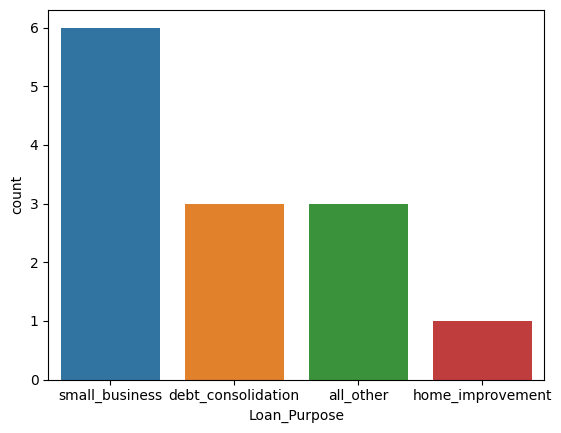

In [32]:
sns.countplot(data=Unpaid_Loan_Purpose_Int_20_Perc,x='Loan_Purpose',hue='Loan_Purpose')
plt.show()

### Small Business Based Cases have Interest Cases Higher Than 20% (Unpaid)

In [34]:
def Debt_Inc_Rat(a):
    if 0<=a<10:
        return '0-9'
    elif 10<=a<20:
        return '10-19'
    else:
        return '>=19'

unpaid['Debt_Income_Ratio_Range']=unpaid['Debt_Income_Ratio'].apply(Debt_Inc_Rat)

In [35]:
Debt_Income_Ratio_Range_Count=pd.DataFrame(unpaid['Debt_Income_Ratio_Range'].value_counts())
Debt_Income_Ratio_Range_Count.reset_index(inplace=True)

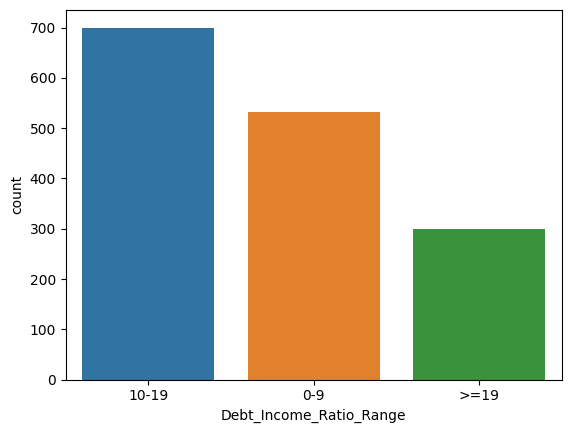

In [36]:
sns.barplot(data=Debt_Income_Ratio_Range_Count,x='Debt_Income_Ratio_Range',y='count',hue='Debt_Income_Ratio_Range')
plt.show()

### Here, We See the Higher the Debt-Income Ratio, the more cases will become Unpaid

## The Purposes which have higher Derogatory Records

In [39]:
unpaid['Count']=1

In [40]:
unpaid['Public_Derogatory_Records']=unpaid['Public_Derogatory_Records'].astype(str)

In [41]:
x1=pd.DataFrame(unpaid.groupby(['Loan_Purpose','Public_Derogatory_Records'])['Count'].sum())
x1.reset_index(inplace=True)

In [42]:
New=x1.loc[x1['Public_Derogatory_Records'].isin(['1'])].sort_values('Count',ascending=False)

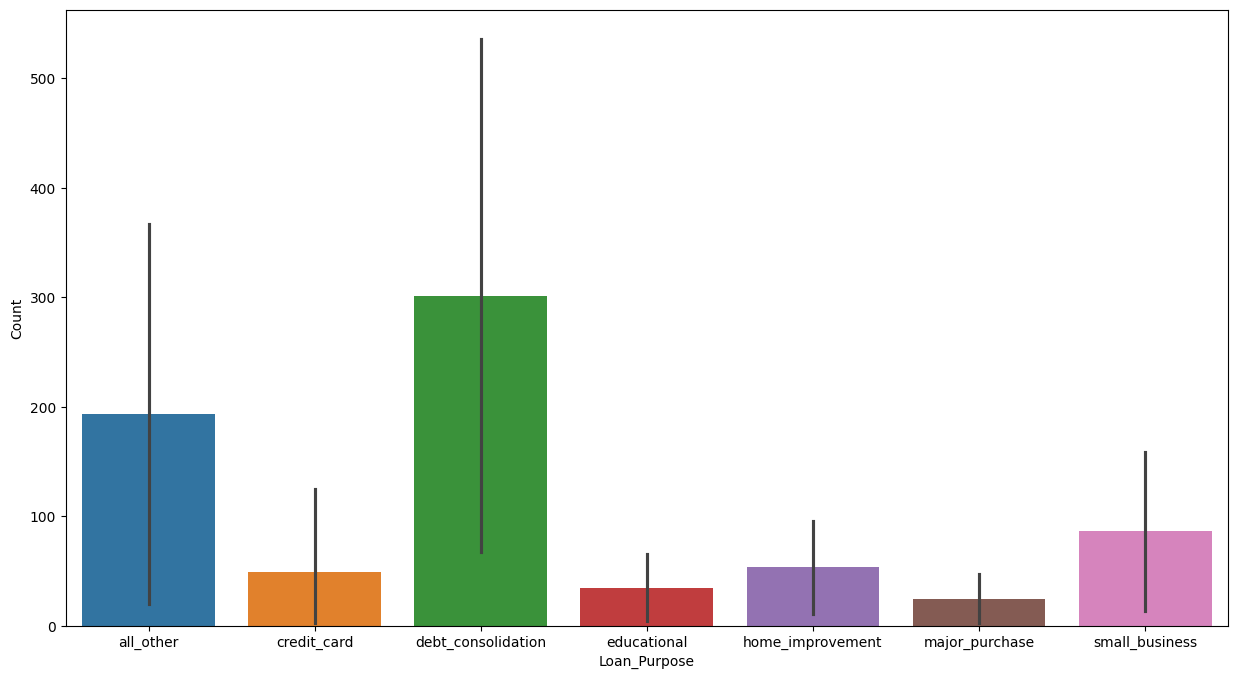

In [43]:
plt.figure(figsize=(15,8))
sns.barplot(data=x1,x='Loan_Purpose',y='Count',hue='Loan_Purpose')
plt.show()

### The debt_consolidation Cases Possesses the More Number of First Time Public Derogatory Records 

# Interest Debt Ratio

In [46]:
Interest_Debt_Ratio=pd.DataFrame(unpaid['Interest_Debt_Income_Ratio'].value_counts())
Interest_Debt_Ratio.reset_index(inplace=True)
Interest_Debt_Ratio

,Interest_Debt_Income_Ratio,count
0,Medium Risk,726
1,Higher Risk,490
2,Lower Risk,317


## The Cases where the Higher Interest & Debt Income Ratio is Higher are the High Risk Customers who fails to pay the Loan

In [48]:
data_copy

,Credit_Policy,Loan_Purpose,Interest_Rate,Monthly_Installment,Natural_log_Annual_Income,Debt_Income_Ratio,FICO_Score,Days_with_Credit_Line,Revolving_Balance,Revolving_Utilization,Enquiries_Last_6_Months,Deliquency_Last_2_Yrs,Public_Derogatory_Records,Paid_Status,Loan_Purpose_Enc,Paid_Status_Enc,Interest_Debt_Ratio,Interest_Debt_Income_Ratio
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,Paid,2,0,2.316172,Higher Risk
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,Paid,1,0,1.530459,Medium Risk
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,Paid,2,0,1.578191,Medium Risk
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,Paid,2,0,0.816480,Medium Risk
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,Paid,1,0,2.134722,Medium Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0,all_other,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,Unpaid,0,1,1.517979,Medium Risk
9574,0,all_other,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,Unpaid,0,1,0.026313,Lower Risk
9575,0,debt_consolidation,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,Unpaid,2,1,1.401939,Medium Risk
9576,0,home_improvement,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,Unpaid,4,1,3.068800,Higher Risk


# Outlier Identification

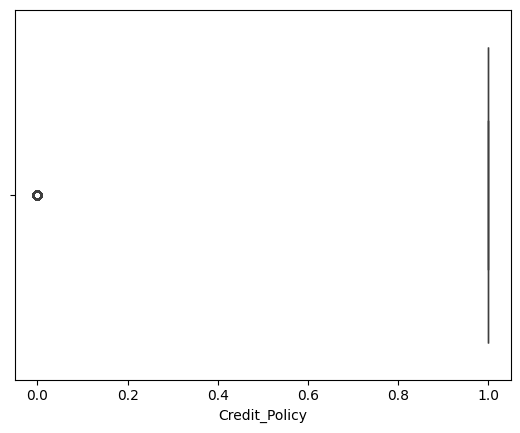

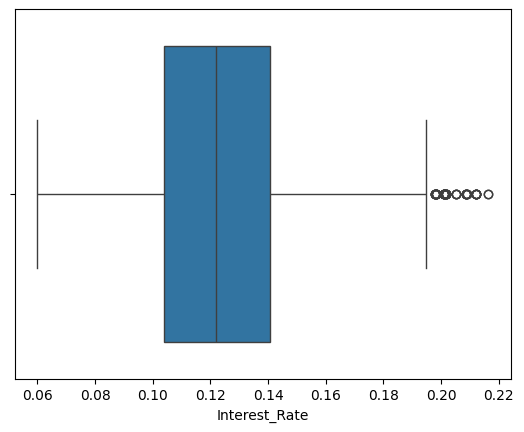

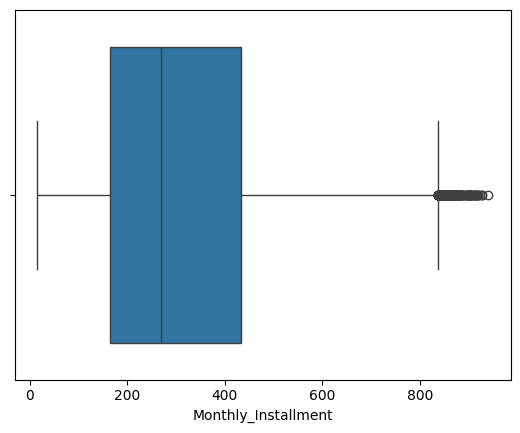

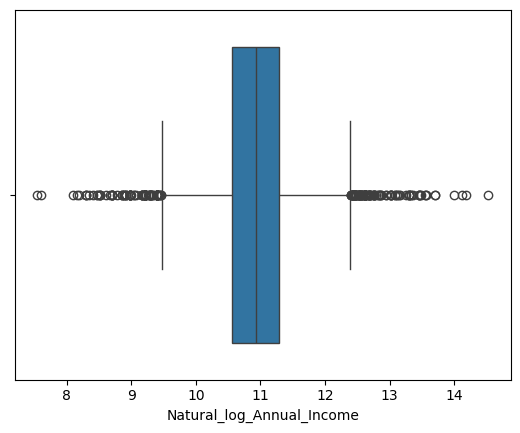

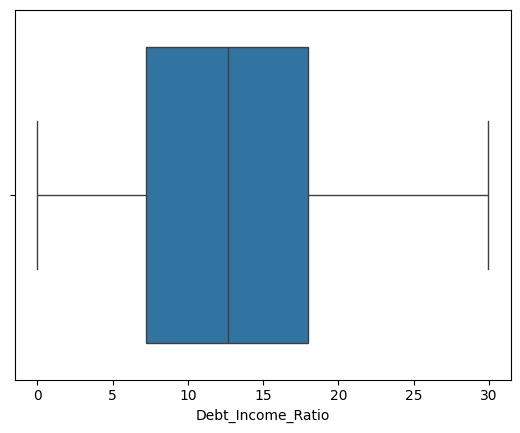

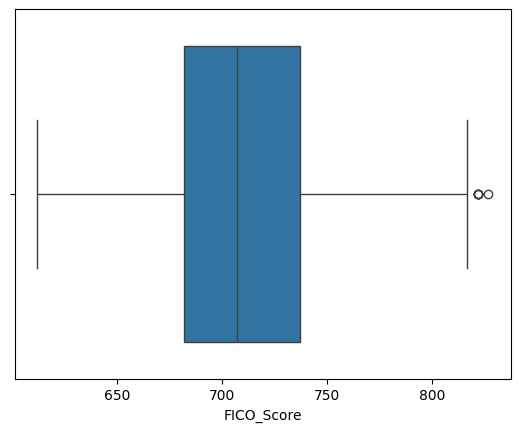

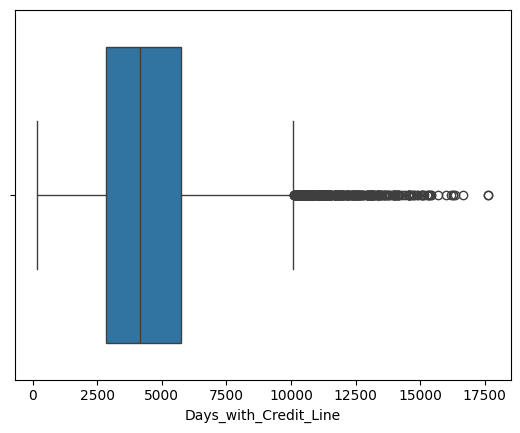

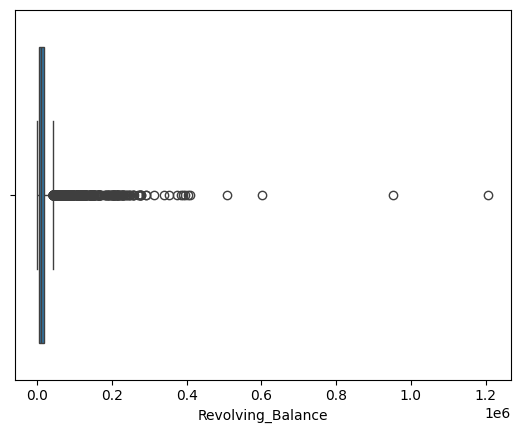

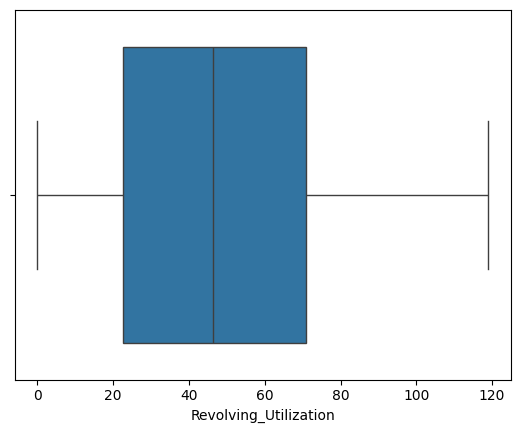

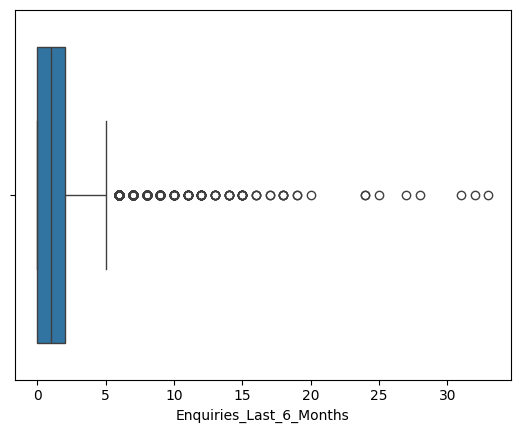

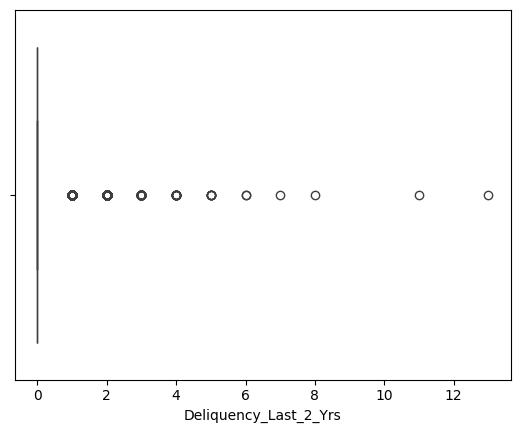

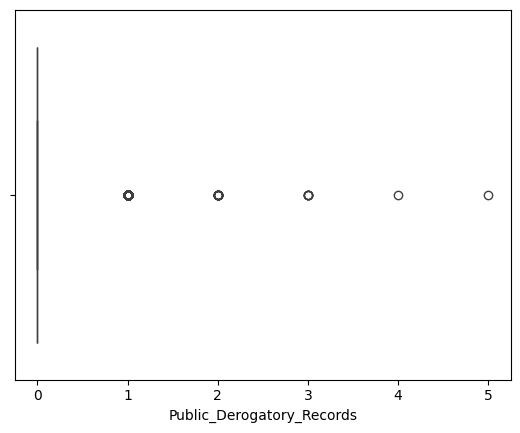

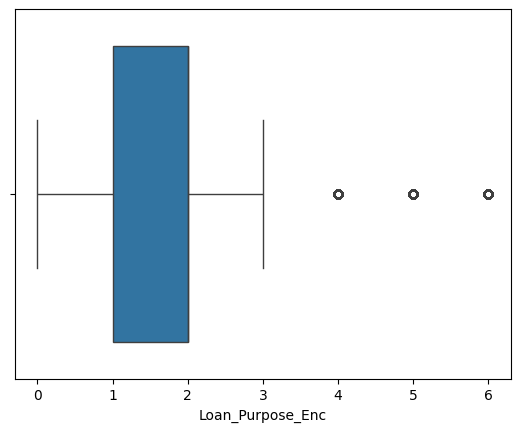

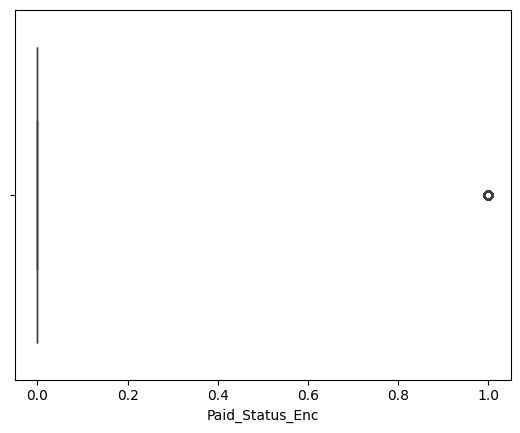

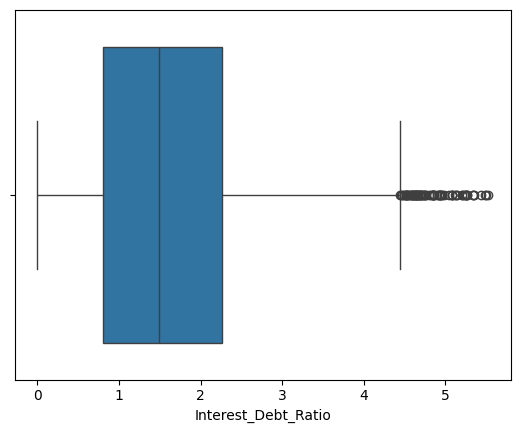

In [50]:
for i in data_num.columns:
    sns.boxplot(data=data_num,x=i)
    plt.show()

### Since The Outliers are Present & The Number of Records are Within 10000, It will be handled in Training Phase